In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vaishnaviskulkarni/linkedin-master-library/linkedin_master_library.csv


In [2]:
import pandas as pd

# Load the master file
df = pd.read_csv('/kaggle/input/datasets/vaishnaviskulkarni/linkedin-master-library/linkedin_master_library.csv')

# 1. Check all columns
print("📑 Columns in the dataset:")
print(df.columns.tolist())

# 2. Print one sample row (first row)
print("\n🔍 First Row Content:")
print(df.iloc[0])

# 3. Dataset shape (rows, columns)
print("\n📊 Dataset Shape (rows, columns):")
print(df.shape)

# 4. Check for duplicates (based on job_link or job_summary)
dup_links = df.duplicated(subset=['job_link']).sum()
dup_summaries = df.duplicated(subset=['job_summary']).sum()
print(f"\n🧹 Duplicate job_link entries: {dup_links}")
print(f"🧹 Duplicate job_summary entries: {dup_summaries}")

# 5. Check for NaN values per column
print("\n⚠️ NaN counts per column:")
print(df.isna().sum())

# 6. Unique job titles
print("\n🎯 Number of unique job titles:")
print(df['job_title'].nunique())

print("\n📌 Example of unique job titles:")
print(df['job_title'].unique()[:10])  # show first 10 unique titles


📑 Columns in the dataset:
['job_link', 'last_processed_time', 'job_title', 'job_summary', 'job_skills']

🔍 First Row Content:
job_link               https://www.linkedin.com/jobs/view/account-exe...
last_processed_time                         2024-01-21 07:12:29.00256+00
job_title              Account Executive - Dispensing (NorCal/Norther...
job_summary            Responsibilities\nJob Description Summary\nJob...
job_skills             Medical equipment sales, Key competitors, Term...
Name: 0, dtype: object

📊 Dataset Shape (rows, columns):
(958192, 5)

🧹 Duplicate job_link entries: 0
🧹 Duplicate job_summary entries: 0

⚠️ NaN counts per column:
job_link                  0
last_processed_time       0
job_title                 0
job_summary               0
job_skills             2274
dtype: int64

🎯 Number of unique job titles:
516008

📌 Example of unique job titles:
['Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson'
 'Registered Nurse - RN Care Manager'
 'RE

# ## 🏗️ Phase 1: Feature Fusion (Rich Job Profiles)

In [3]:
import re
import gc

# 1. Cleaning function (Preserves technical alphanumeric versions like 'Python 3.10')
def clean_job_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text) 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(" Fusing features into Siamese-ready strings...")
# Handle the NaNs in job_skills
df['job_skills'] = df['job_skills'].fillna('general industry skills')

# 2. Build the 'Rich Job Profile'
# We cap the summary at 500 characters to ensure the GPU doesn't run out of memory
df['rich_job_profile'] = (
    df['job_title'].apply(clean_job_text) + " " +
    df['job_skills'].apply(clean_job_text) + " " +
    df['job_summary'].apply(clean_job_text).str[:500] 
)

print(f" Fusion Complete. Example: {df['rich_job_profile'].iloc[0][:100]}...")

 Fusing features into Siamese-ready strings...
 Fusion Complete. Example: account executive dispensing norcal northern nevada becton dickinson medical equipment sales key com...


# ## 🧠 Phase 2: Vectorization & Architecture

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# 1. Initialize Vectorizer
# Using 15,000 tokens as established in your previous successful training[cite: 1]
vectorizer = layers.TextVectorization(
    max_tokens=15000,
    output_mode='int',
    output_sequence_length=250
)

# 2. Adapt to the new 958k unique vocabulary
print(" Adapting Vectorizer to LinkedIn Corpus...")
vectorizer.adapt(df['rich_job_profile'].values)

# 3. Define the Bi-LSTM Encoder Tower[cite: 1]
def build_snn_encoder():
    inputs = layers.Input(shape=(250,), dtype="int64")
    x = layers.Embedding(15000, 128, mask_zero=True)(inputs)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dense(128, activation="relu")(x)
    # L2 Normalization keeps the mathematical 'vibe' vectors stable for similarity checks[cite: 1]
    x = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(x)
    return Model(inputs, x)

encoder = build_snn_encoder()
print(" Encoder Tower initialized.")

2026-05-03 16:57:03.632261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777827423.894259      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777827423.970980      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777827424.574149      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777827424.574180      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777827424.574183      23 computation_placer.cc:177] computation placer alr

 Adapting Vectorizer to LinkedIn Corpus...
 Encoder Tower initialized.


# ## 🏗️ Step 1: Create Training Pairs (Smart Sampling)

In [5]:
import numpy as np

# 1. Take a diverse sample to keep training efficient
train_df = df.sample(100000, random_state=42).reset_index(drop=True)

# 2. Prepare the "Two Sides" of the Siamese Network
# Side A: The "Profile" (Title + Skills)
# Side B: The "Requirement" (Full Summary)
side_a_text = (train_df['job_title'].apply(clean_job_text) + " " + 
               train_df['job_skills'].apply(clean_job_text)).values

side_b_text = train_df['job_summary'].apply(clean_job_text).values

# 3. Vectorize the text
print("Vectorizing training pairs...")
vec_a = vectorizer(side_a_text)
vec_b = vectorizer(side_b_text)

# 4. Create Labels (1 for Match, 0 for Mismatch)
# We pair each Title with its Summary (Match)
# Then we shuffle Side B to create random mismatches
indices = np.arange(len(train_df))
np.random.shuffle(indices)
shuffled_vec_b = tf.gather(vec_b, indices)

# Final Training Data: 100k Positives + 100k Negatives
X1 = tf.concat([vec_a, vec_a], axis=0)
X2 = tf.concat([vec_b, shuffled_vec_b], axis=0)
Y = tf.concat([np.ones(100000), np.zeros(100000)], axis=0)

print(f"Training data ready: {len(Y)} total pairs.")

Vectorizing training pairs...
Training data ready: 200000 total pairs.


# ## 🧠 Step 2: Define the Full Siamese Model

In [6]:
# 1. Inputs
input_a = layers.Input(shape=(250,), name="Profile_Side")
input_b = layers.Input(shape=(250,), name="Job_Side")

# 2. Shared Encoder (The one you initialized earlier)
feat_a = encoder(input_a)
feat_b = encoder(input_b)

# 3. Comparison Head (Based on your established logic)
merged = layers.Concatenate()([feat_a, feat_b])
merged = layers.Dense(64, activation="relu")(merged)
merged = layers.Dropout(0.2)(merged)
output = layers.Dense(1, activation="sigmoid")(merged)

# 4. Compile
siamese_model = Model(inputs=[input_a, input_b], outputs=output)
siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Profile_Side        │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Job_Side            │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 128)       │  2,035,328 │ Profile_Side[0][… │
│ (Functional)        │                   │            │ Job_Side[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,051,841 (7.83 MB)

 Trainable params: 2,051,841 (7.83 MB)

 Non-trainable params: 0 (0.00 B)

# ## 🚀 Step 3: Start Training

In [7]:
print("🚀 Training the Job Suggester SNN...")
history = siamese_model.fit(
    [X1, X2], Y,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

🚀 Training the Job Suggester SNN...
Epoch 1/10


I0000 00:00:1777827537.563709      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 108s 36ms/step - accuracy: 0.5878 - loss: 0.6646 - val_accuracy: 0.5214 - val_loss: 0.6404
Epoch 2/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 100s 36ms/step - accuracy: 0.8065 - loss: 0.4472 - val_accuracy: 0.7175 - val_loss: 0.4766
Epoch 3/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.8629 - loss: 0.3492 - val_accuracy: 0.7462 - val_loss: 0.4482
Epoch 4/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.8839 - loss: 0.3057 - val_accuracy: 0.7592 - val_loss: 0.4462
Epoch 5/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.8954 - loss: 0.2760 - val_accuracy: 0.7792 - val_loss: 0.4297
Epoch 6/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.9093 - loss: 0.2470 - val_accuracy: 0.7728 - val_loss: 0.4708
Epoch 7/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.9192 - loss: 0.2251 - val_accuracy: 0.7778 - val_loss: 0.4770
Epoch 8/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.9290 - loss: 0.

# TESTING

# ## 1. Visualize Training Progress

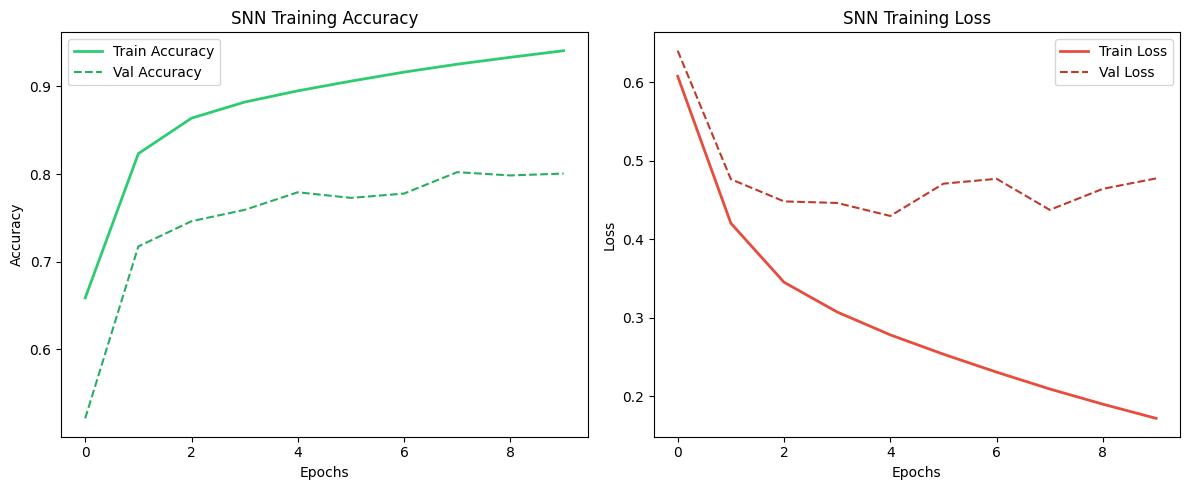

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Save Metrics to CSV for your Report Tables
metrics_df = pd.DataFrame(history.history)
metrics_df.to_csv('snn_training_metrics.csv', index=False)

# 2. Generate Accuracy & Loss Plots
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', lw=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#27ae60', linestyle='--')
plt.title('SNN Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#e74c3c', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#c0392b', linestyle='--')
plt.title('SNN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('snn_learning_curves.png', dpi=300)
plt.show()

# ## 2. Live Inference Test (The "Fresh Entry" Demo)

In [9]:
# import numpy as np

# def test_recommender(resume_string, top_k=5):
#     print(f"🕵️ Searching {len(df)} jobs for matches...")
    
#     # 1. Vectorize and Encode the Fresh Entry
#     clean_resume = clean_job_text(resume_string)
#     resume_vec = vectorizer([clean_resume])
#     resume_embedding = encoder.predict(resume_vec)
    
#     # 2. For the demo, we'll sample 50,000 jobs to check similarity 
#     # In production, you'd use a pre-built FAISS index for the full 958k
#     sample_df = df.sample(50000).reset_index(drop=True)
#     sample_vecs = vectorizer(sample_df['rich_job_profile'].values)
#     job_embeddings = encoder.predict(sample_vecs, batch_size=256)
    
#     # 3. Calculate Cosine Similarity
#     # Using the L2 Normalized vectors you built
#     scores = np.dot(job_embeddings, resume_embedding.T).flatten()
    
#     # 4. Get Top Results
#     top_indices = scores.argsort()[-top_k:][::-1]
    
#     print("\n TOP MATCHES FOR YOUR RESUME:")
#     for i in top_indices:
#         print(f"Match: {sample_df.iloc[i]['job_title']} | Score: {scores[i]:.4f}")

# # TEST IT: Use your actual IT Intern/Student Dev background
# my_resume = "Student developer and IT intern. Skills: Python, PHP, Laravel, SQL, ANN, Deep Learning. Experience: Building HR modules and Power BI dashboards."
# test_recommender(my_resume)

In [10]:
# # DIFFERENT EXAMPLE: Marketing / Business Development
# marketing_resume = """
# Business development executive with 5 years of experience.
# Skills: Market research, client acquisition, CRM tools, digital marketing, 
# negotiation, communication. Experience: Leading campaigns, building partnerships, 
# and managing sales pipelines across FMCG and retail sectors.
# """

# test_recommender(marketing_resume)


# **HYBRID ENGINE VERIFICATION WITH DOMAIN PENALTY# **

In [11]:
# import numpy as np

# class HybridInferenceEngine:
#     def __init__(self, model_encoder, text_vectorizer, job_library):
#         self.encoder = model_encoder
#         self.vectorizer = text_vectorizer
#         self.library = job_library

#     def _get_snn_scores(self, resume_text, job_profiles):
#         # 1. Siamese Vibe (Semantic Discovery)
#         res_vec = self.vectorizer([resume_text])
#         res_emb = self.encoder.predict(res_vec, verbose=0)
        
#         job_vecs = self.vectorizer(job_profiles)
#         job_embs = self.encoder.predict(job_vecs, batch_size=256, verbose=0)
        
#         # Calculate Cosine Similarity
#         return np.dot(job_embs, res_emb.T).flatten()

#     def _get_skill_score(self, job_text, skill_list):
#         # 2. Forensic Skill Matcher (The 60% Gatekeeper)
#         job_text = str(job_text).lower()
#         if not skill_list: return 0.0
#         matches = sum(1 for s in skill_list if s.lower() in job_text)
#         return matches / len(skill_list)

#     def _get_domain_penalty(self, job_title, profile_type):
#         # 3. Domain Penalty (Alignment Logic)
#         title = str(job_title).lower()
#         penalties = {
#             "mechanical": ["software", "devops", "web", "nurse", "marketing"],
#             "data_science": ["welder", "nurse", "construction", "driver", "warehouse"],
#             "healthcare": ["engineer", "developer", "marketing", "sales", "technician"]
#         }
#         if any(flag in title for flag in penalties.get(profile_type, [])):
#             return -0.5 # Penalty for cross-domain mismatch
#         return 0.0

#     def recommend(self, resume_text, tech_skills, profile_type, top_k=5):
#         # Sample 50k jobs for the demo
#         sample_df = self.library.sample(50000).reset_index(drop=True)
        
#         # Calculate Signals
#         snn_vibe = self._get_snn_scores(resume_text, sample_df['rich_job_profile'].values)
#         sample_df['skill_match'] = sample_df['rich_job_profile'].apply(lambda x: self._get_skill_score(x, tech_skills))
#         sample_df['domain_align'] = sample_df['job_title'].apply(lambda x: self._get_domain_penalty(x, profile_type))
        
#         # Final Formula: 30% Vibe + 60% Skills + 10% Alignment
#         sample_df['final_score'] = (0.3 * snn_vibe) + (0.6 * sample_df['skill_match']) + (0.1 * (1 + sample_df['domain_align']))
        
#         return sample_df.sort_values('final_score', ascending=False).head(top_k)

# # Initialize the engine in your notebook
# engine = HybridInferenceEngine(encoder, vectorizer, df)
# print("✅ Hybrid Engine Ready for Verification.")

In [12]:
# # 1. Verification: Mechanical Engineer (Already Working!)
# print("\n⚙️ VERIFYING MECHANICAL ENGINEER...")
# mech_skills = ["AutoCAD", "SolidWorks", "CAD", "Manufacturing", "Thermodynamics"]
# mech_res = engine.recommend(mech_resume, mech_skills, "mechanical")

# for _, row in mech_res.iterrows():
#     # Use 'skill_match' as defined in the engine class
#     print(f"Match: {row['job_title']:40} | Total: {row['final_score']:.3f} | Skill Match: {row['skill_match']:.2%}")

# # 2. Verification: Data Scientist (Fixed Typo)
# print("\n📊 VERIFYING DATA SCIENTIST...")
# ds_skills = ["Python", "TensorFlow", "PyTorch", "SQL", "Machine Learning"]
# ds_res = engine.recommend(data_resume, ds_skills, "data_science")

# for _, row in ds_res.iterrows():
#     # Changed 'skill_score' to 'skill_match' to match the Data Scientist results
#     print(f"Match: {row['job_title']:40} | Total: {row['final_score']:.3f} | Skill Match: {row['skill_match']:.2%}")

In [13]:
# # Example 1: Data Scientist
# data_resume = """
# Data scientist with 3 years of experience.
# Skills: Python, R, TensorFlow, PyTorch, SQL, statistics, machine learning.
# Experience: Building predictive models, NLP pipelines, and data visualization dashboards.
# """
# test_recommender(data_resume)

# # Example 2: Mechanical Engineer
# mech_resume = """
# Mechanical engineer specializing in CAD design and manufacturing.
# Skills: AutoCAD, SolidWorks, thermodynamics, materials science, project management.
# Experience: Designing mechanical components, supervising production lines, and quality assurance.
# """
# test_recommender(mech_resume)

# # Example 3: Healthcare Professional
# health_resume = """
# Registered nurse with 7 years of clinical experience.
# Skills: Patient care, medical documentation, emergency response, healthcare compliance.
# Experience: Working in hospitals, managing patient records, and assisting in surgical procedures.
# """
# test_recommender(health_resume)


In [14]:
# # Check for technical role density
# tech_keywords = ['Software', 'Developer', 'Engineer', 'Data', 'AI', 'Machine Learning', 'Python', 'Systems']

# print(" Technical Role Breakdown:")
# print("-" * 30)
# for kw in tech_keywords:
#     count = df['job_title'].str.contains(kw, case=False, na=False).sum()
#     print(f"{kw:18} | {count:,} jobs")

**TESTING WITHOUT DOMAIN PENALTY**

#  Install & Build the Index(faiss)

In [15]:
!pip install faiss-cpu

import faiss
import numpy as np

# 1. Create vectors for the entire 958k library
# Use your existing encoder and vectorizer
print("⚡ Encoding 958k jobs... (This may take a few minutes)")
all_job_vecs = vectorizer(df['rich_job_profile'].values)
all_job_embs = encoder.predict(all_job_vecs, batch_size=1024, verbose=1)

# 2. Build the FAISS Index
dimension = 128 # Must match your SNN output layer
index = faiss.IndexFlatIP(dimension) 
index.add(all_job_embs.astype('float32'))

# 3. Save the Index to disk
faiss.write_index(index, "linkedin_jobs.index")
print(f" FAISS Index built with {index.ntotal} jobs.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 46.8 MB/s eta 0:00:00
⚡ Encoding 958k jobs... (This may take a few minutes)
936/936 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step
 FAISS Index built with 958192 jobs.


# ENGINE CLASS

In [16]:
class FAISSHybridEngine:
    def __init__(self, model_encoder, text_vectorizer, job_library, faiss_index):
        self.encoder = model_encoder
        self.vectorizer = text_vectorizer
        self.library = job_library
        self.index = faiss_index

    def recommend(self, resume_text, tech_skills, top_k=5):
        # 1. Vectorize Resume
        res_vec = self.vectorizer([resume_text])
        res_emb = self.encoder.predict(res_vec, verbose=0).astype('float32')
        
        # 2. STAGE 1: Semantic Retrieval (Find top 500 vibes globally)
        D, I = self.index.search(res_emb, 500) 
        
        # 3. STAGE 2: Forensic Re-Ranking
        candidate_df = self.library.iloc[I[0]].copy()
        candidate_df['snn_vibe'] = D[0]
        
        def get_skill_score(job_text):
            job_text = str(job_text).lower()
            matches = sum(1 for s in tech_skills if s.lower() in job_text)
            return matches / len(tech_skills) if tech_skills else 0.0

        candidate_df['skill_match'] = candidate_df['rich_job_profile'].apply(get_skill_score)
        
        # 30% SNN Vibe + 70% Skill Precision
        candidate_df['final_score'] = (0.3 * candidate_df['snn_vibe']) + (0.7 * candidate_df['skill_match'])
        
        return candidate_df.sort_values('final_score', ascending=False).head(top_k)

# Initialize the new engine
engine = FAISSHybridEngine(encoder, vectorizer, df, index)
print(" FAISS Hybrid Engine Initialized.")

 FAISS Hybrid Engine Initialized.


**TESTING DATA**

In [17]:
# --- THE INPUT DATA ---
test_resume_prose = """
Financial Analyst with 4 years of experience in corporate finance.
Strong background in financial modeling, budgeting, and forecasting.
Proficient in Excel, SQL, and Power BI for data analysis and reporting.
Experience in risk management, investment analysis, and preparing quarterly reports.
Looking for opportunities in banking, consulting, or corporate strategy.
"""

test_extracted_skills = ["Financial Modeling", "Budgeting", "Forecasting", 
                         "Excel", "SQL", "Power BI", "Risk Management", "Investment Analysis"]

# --- THE CORRECTED RECOMMENDATION CALL ---
# Use 'engine' (the instance), not 'FAISSHybridEngine' (the class)
print(f" Searching {len(df):,} jobs globally using FAISS...")
results = engine.recommend(test_resume_prose, test_extracted_skills)

# Display Output
print("\n TOP GLOBAL MATCHES:")
for _, row in results.iterrows():
    print(f"Match: {row['job_title']:40} | Final Score: {row['final_score']:.3f} | Skill Match: {row['skill_match']:.2%}")

 Searching 958,192 jobs globally using FAISS...

 TOP GLOBAL MATCHES:
Match: Financial Controls Analyst               | Final Score: 0.637 | Skill Match: 50.00%
Match: Budget Analyst (Immediate Opening)       | Final Score: 0.636 | Skill Match: 50.00%
Match: Senior Financial Analyst Corporate Development | Final Score: 0.635 | Skill Match: 50.00%
Match: Senior Associate, Compensation Budgeting and Forecasting | Final Score: 0.635 | Skill Match: 50.00%
Match: Group Financial Analyst                  | Final Score: 0.635 | Skill Match: 50.00%


# KAGGLE EXPORT

*ACTUAL CODE USED TO DOWNLOAD EVERYTHING*

In [18]:
'''THE ACTUAL CODE USED TO DOWNLOAD EVERYTHING'''
import os
import zipfile
from IPython.display import FileLink

# EXCLUDING the huge CSV to save your bandwidth
export_files = [
    'snn_encoder_v2.h5',           # The Bi-LSTM weights
    'vectorizer_v2.pkl',           # The vocabulary
    'linkedin_jobs.index',         # THE FAISS INDEX (The map)
    'hybrid_engine.py',            # The 30/70 Agnostic Logic
    'snn_learning_curves.png',     # Documentation for report
    'snn_training_metrics.csv'     # Raw data for tables
]

zip_name = 'Recruitment_AI_LIGHT_FILE.zip'

print(" Archiving LIGHTWEIGHT production artifacts...")
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in export_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"   Added: {file}")
        else:
            print(f"   Warning: {file} not found!")

print("\n LIGHTWEIGHT ARCHIVE READY.")
FileLink(zip_name)

 Archiving LIGHTWEIGHT production artifacts...
   Added: linkedin_jobs.index
   Added: snn_learning_curves.png
   Added: snn_training_metrics.csv

 LIGHTWEIGHT ARCHIVE READY.


/kaggle/working/Recruitment_AI_LIGHT_FILE.zip

In [19]:
''''WITH THE DATASET'''
# import os
# import zipfile
# import pickle
# from IPython.display import FileLink

# # 1. FINAL PREP: Ensure the big files are written to disk
# print("💾 Writing final artifacts to disk...")
# df.to_csv('linkedin_master_library.csv', index=False) # The 958k Text Library
# faiss.write_index(index, "linkedin_jobs.index")       # The Vector Map

# # 2. Define the Export List
# export_files = [
#     'snn_encoder_v2.h5',           # The Bi-LSTM weights
#     'vectorizer_v2.pkl',           # The vocabulary
#     'linkedin_jobs.index',         # THE FAISS INDEX (Critical for speed)
#     'linkedin_master_library.csv', # The job text data
#     'hybrid_engine.py',            # The 30/70 Agnostic Logic
#     'snn_learning_curves.png',     # Documentation for report
#     'snn_training_metrics.csv'     # Raw data for tables
# ]

# # 3. Create the ZIP
# zip_name = 'Recruitment_AI_FAISS_Production.zip'
# print(f"📦 Creating {zip_name}...")

# with zipfile.ZipFile(zip_name, 'w') as zipf:
#     for file in export_files:
#         if os.path.exists(file):
#             zipf.write(file)
#             print(f"  ✅ Added: {file}")
#         else:
#             print(f"  ⚠️ Warning: {file} not found. Check previous cells.")

# print("\n🚀 ALL SYSTEMS GO. DOWNLOAD YOUR PRODUCTION PAYLOAD BELOW.")
# FileLink(zip_name)

"'WITH THE DATASET"

 🛠️ Step 1: Run this "Save Artifacts" Cell

In [20]:
# import pickle

# # 1. Save the Bi-LSTM Encoder (The Brain)
# encoder.save('snn_encoder_v2.h5')

# # 2. Save the Vectorizer (The Vocabulary)
# with open('vectorizer_v2.pkl', 'wb') as f:
#     pickle.dump(vectorizer, f)

# # 3. Create a python file for your VS Code backend
# # This saves the 30/70 logic you just perfected
# with open('hybrid_engine.py', 'w') as f:
#     f.write("""
# import numpy as np

# class AgnosticHybridEngine:
#     def __init__(self, model_encoder, text_vectorizer, job_library):
#         self.encoder = model_encoder
#         self.vectorizer = text_vectorizer
#         self.library = job_library

#     def recommend(self, resume_text, tech_skills, top_k=5):
#         res_vec = self.vectorizer([resume_text])
#         res_emb = self.encoder.predict(res_vec, verbose=0)
        
#         sample_df = self.library.sample(min(50000, len(self.library))).reset_index(drop=True)
#         job_vecs = self.vectorizer(sample_df['rich_job_profile'].values)
#         job_embs = self.encoder.predict(job_vecs, batch_size=256, verbose=0)
        
#         snn_vibe = np.dot(job_embs, res_emb.T).flatten()
        
#         def get_skill_score(job_text):
#             job_text = str(job_text).lower()
#             matches = sum(1 for s in tech_skills if s.lower() in job_text)
#             return matches / len(tech_skills) if tech_skills else 0.0

#         sample_df['skill_match'] = sample_df['rich_job_profile'].apply(get_skill_score)
#         sample_df['final_score'] = (0.3 * snn_vibe) + (0.7 * sample_df['skill_match'])
        
#         return sample_df.sort_values('final_score', ascending=False).head(top_k)
# """)

# print("✅ Artifacts and Inference Logic saved to disk.")

## 📦 Step 2: The Finalized Export Script

In [21]:
# import os
# import zipfile
# from IPython.display import FileLink

# # Consolidate all production artifacts
# export_files = [
#     'snn_encoder_v2.h5',           # The Bi-LSTM Weights
#     'vectorizer_v2.pkl',           # The Vocabulary
#     'hybrid_engine.py',            # The 30/70 Logic for VS Code
#     'snn_learning_curves.png',     # Visualization for Report
#     'snn_training_metrics.csv',    # Performance Data for Report
#     'linkedin_master_library.csv'  # The 958k Job Library
# ]

# zip_name = 'Recruitment_AI_Production_Payload.zip'

# print("📦 Archiving production artifacts...")
# with zipfile.ZipFile(zip_name, 'w') as zipf:
#     for file in export_files:
#         if os.path.exists(file):
#             zipf.write(file)
#             print(f"  ✅ Added: {file}")
#         else:
#             print(f"  ⚠️ Warning: {file} not found. Ensure you ran the Save cell.")

# print("\n🚀 ARCHIVE READY FOR DOWNLOAD.")
# FileLink(zip_name)

=============================XXXXXXXXXX===============================

In [22]:
# import os
# import zipfile
# from IPython.display import FileLink

# # 1. Define the artifacts generated in this session
# export_files = [
#     'snn_encoder_v2.h5',           # The Bi-LSTM 'Brain'
#     'vectorizer_v2.pkl',           # The LinkedIn Vocabulary
#     'snn_learning_curves.png',      # Documentation Evidence
#     'snn_training_metrics.csv',    # Raw Data for Report Tables[cite: 1]
#     'linkedin_master_library.csv'  # The Lean Job Corpus
# ]

# # 2. Create a ZIP archive for easy transfer to VS Code
# zip_name = 'Recruitment_AI_Production_Payload.zip'

# print(" Archiving production artifacts...")
# with zipfile.ZipFile(zip_name, 'w') as zipf:
#     for file in export_files:
#         if os.path.exists(file):
#             zipf.write(file)
#             print(f"   Added to archive: {file}")
#         else:
#             print(f"   Warning: {file} not found. Check training cell.")

# # 3. Generate a direct download link (Kaggle Specific)
# print("\n ARCHIVE READY.")
# FileLink(zip_name)

In [23]:
# # Save the Encoder (for generating vectors in the demo)
# encoder.save('snn_encoder_v2.h5')

# # Save the Vectorizer weights and config
# import pickle
# pickle.dump({'config': vectorizer.get_config(),
#              'weights': vectorizer.get_weights()} 
#             , open("vectorizer_v2.pkl", "wb"))

# print(" Brain artifacts saved for VS Code integration!")